# Contexto Social y Motivación del Estudio
- escribir texto

## Diseño del Muestreo y Levantamiento de Datos
- escribir texto 

In [4]:
from IPython.display import Markdown
import json

with open("prueba.json", "r", encoding="utf-8") as f:
    pimes_json = json.load(f)

with open("prueba_online.json", "r", encoding="utf-8") as f:
    pimeson_json = json.load(f)

tabla_fisica = "| Tienda | Latitud | Longitud | Evidence |\n"
tabla_fisica += "|--------|----------|-----------|-----------|\n"

for item in pimes_json:
    tabla_fisica += f"| {item['name']} | {item['latitude']} | {item['length']} | {item['evidence']} |\n"

tabla_online = "| Tienda | App | Link | Evidence |\n"
tabla_online += "|--------|----------|----------|-----------|\n"

for item in pimeson_json:
    tabla_online += f"| {item['name']} | {item['canal']} | {item['link']} | {item['evidence']} |\n"

display(Markdown("### Tiendas Físicas"))
display(Markdown(tabla_fisica))
display(Markdown("### Tiendas Online"))
display(Markdown(tabla_online))

### Tiendas Físicas

| Tienda | Latitud | Longitud | Evidence |
|--------|----------|-----------|-----------|
| VER PARA CREER S.U.R.L | 58468453168 | 84763135684 | p/mojon.png |
| Z PEREZ S.U.R.L. | 461815 | 1684865415 | p/serio.png |


### Tiendas Online

| Tienda | App | Link | Evidence |
|--------|----------|----------|-----------|
| la cuevita | telegram | wpswjrkfbwr | p/mojon.png |
| oe si | wasap | wehbfE | p/serio.png |


## Impacto Salarial de la Compra Mensual
- escribir texto

In [16]:
import plotly.express as px
import datos_static 
# tus valores ya existen
canasta_off = [datos_static.precio_canasta_off, datos_static.salario_medio - datos_static.precio_canasta_off]
labels_off  = ["Canasta física", "Resto del salario"]

fig_off = px.pie(values=canasta_off, names=labels_off,
            title="Canasta física vs salario mensual",
            color_discrete_sequence=["#4c72b0","#55a868"])
fig_off.update_traces(
    texttemplate="%{percent:.2%}"
)
fig_off.show()

canasta_on = [datos_static.precio_canasta_on, datos_static.salario_medio - datos_static.precio_canasta_on]
labels_on = ["Canasta on-line", "Resto del salario"]

fig_on = px.pie(values=canasta_on, names=labels_on,
                title="Canasta online vs salario mensula", 
                color_discrete_sequence=["#4c72b0","#55a868"])
fig_on.update_traces(
    texttemplate="%{percent:.2%}"
)
fig_on.show()    

## Comparación del Costo Promedio por Producto
- escribir texto


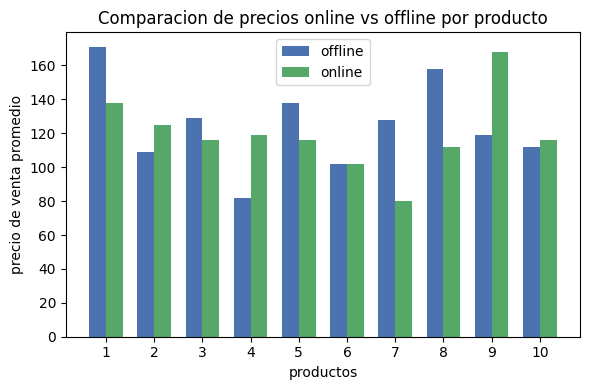

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import dic_work

# Preparar datos para matplotlib
productos = dic_work.lst_productos
barra1   = dic_work.lst_promedio_off
barra2   = dic_work.lst_promedio_on

x = np.arange(len(productos))        # posiciones de las categorías
color_off="#4c72b0"
color_on="#55a868"

# Graficar
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.35/2, barra1, 0.35, color=color_off, label="offline")
ax.bar(x + 0.35/2, barra2, 0.35, color=color_on, label="online")

ax.set_xlabel("productos")
ax.set_ylabel("precio de venta promedio")
ax.set_title("Comparacion de precios online vs offline por producto")
ax.set_xticks(x)
ax.set_xticklabels(productos)
ax.legend()

plt.tight_layout()
plt.show()

## Calculo del diff 
- escribir texto

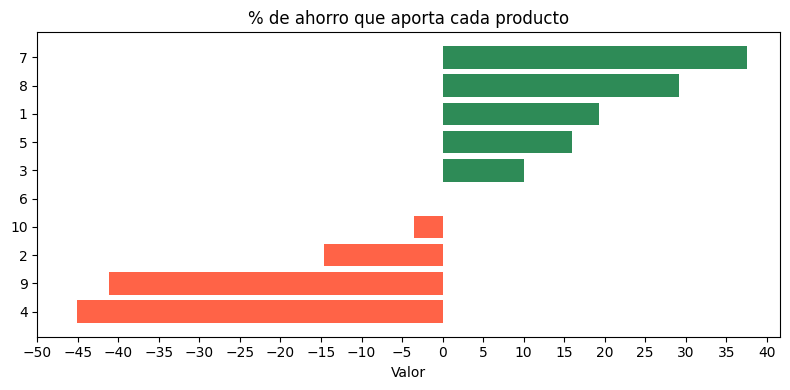

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import dic_work  

categorias = dic_work.lst_productos
valores    = dic_work.lst_diff

colores = []
for v in valores:
    if v < 0:
        colores.append("tomato")
    elif v < 5:
        colores.append("yellow")
    else:
        colores.append("seagreen")

# ordenar de mayor a menor según el valor
orden = sorted(range(len(valores)), key=lambda i: valores[i], reverse=True)
categorias = [categorias[i] for i in orden]
valores    = [valores[i]    for i in orden]
colores    = [colores[i]    for i in orden]

plt.figure(figsize=(8, 4))
plt.barh(categorias, valores, color=colores)
plt.xlabel("Valor")
plt.title("% de ahorro que aporta cada producto")
plt.gca().invert_yaxis()
plt.tight_layout()

# ticks del eje X cada 5 unidades
min_x, max_x = min(valores), max(valores)
plt.xticks(np.arange(np.floor(min_x/5)*5,
                    np.ceil(max_x/5)*5 + 5, 5))

plt.show()

## Rango de variacion entre empresas por producto 
- escribir texto

In [9]:
from IPython.display import Markdown
import json
import dic_work
import metodos_pruebas

with open("prueba.json", "r") as f:
    pimes_json = json.load(f)

tabla = "| Producto | Tienda | OnLine |\n"
tabla += "|----------|-----------|-----------|\n"
tabla += f" {metodos_pruebas.convertir_tabla(dic_work.lst_productos, dic_work.lst_rango_off, dic_work.lst_rango_on)}"

Markdown(tabla)

| Producto | Tienda | OnLine |
|----------|-----------|-----------|
 | 1 | 3 | 30 |
| 2 | 19 | 35 |
| 3 | 39 | 12 |
| 4 | 14 | 11 |
| 5 | 30 | 20 |
| 6 | 70 | 72 |
| 7 | 46 | 10 |
| 8 | 10 | 26 |
| 9 | 11 | 0 |
| 10 | 16 | 20 |


## Rankin de daño por canal
- escribir texto

In [11]:
from IPython.display import Markdown
import dic_work

tabla_off = "| Tienda | Canasta | {%} |\n"
tabla_off += "|-----------|------------|--------------|\n"

for key, value in dic_work.dic_off_canasta.items():
    tabla_off += f"| {key} | {value[0]} | {round(value[1], 2)} |\n"

tabla_on = "| Tienda | Canasta | {%} |\n"
tabla_on += "|-----------|----------|------------|\n"

for key, value in dic_work.dic_on_canasta.items():
    tabla_on += f"| {key} | {value[0]} | {round(value[1], 2)} |\n"

display(Markdown("### Tiendas en Fisico"))
display(Markdown(tabla_off))
display(Markdown("### Tiendas OnLine"))
display(Markdown(tabla_on))

### Tiendas en Fisico

| Tienda | Canasta | {%} |
|-----------|------------|--------------|
| VER PARA CREER S.U.R.L | 714 | 33.71 |
| Z PEREZ S.U.R.L. | 534 | 0.0 |


### Tiendas OnLine

| Tienda | Canasta | {%} |
|-----------|----------|------------|
| la cuevita | 539 | 0.0 |
| oe si | 653 | 21.15 |


## Lollipop (punto anterior)
- escribir texto

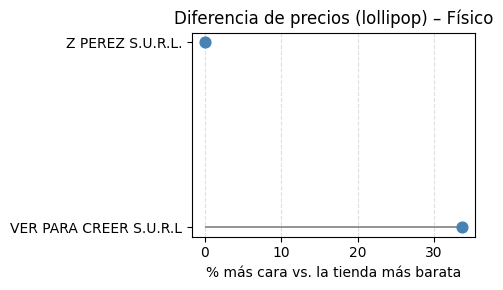

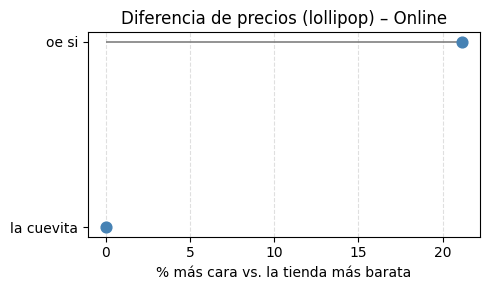

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import dic_work  

# Offline
tiendas_off = []
pct_mas_cara_off = []

for key, value in dic_work.dic_off_canasta.items():
    tiendas_off.append(key)
    pct_mas_cara_off.append(value[1])

y_pos = np.arange(len(tiendas_off))

fig, ax = plt.subplots(figsize=(5, 3))
ax.hlines(y_pos, xmin=0, xmax=pct_mas_cara_off, color="grey", linewidth=1.2)
ax.scatter(pct_mas_cara_off, y_pos, color="steelblue", zorder=3, s=60)

ax.set_yticks(y_pos)
ax.set_yticklabels(tiendas_off)
ax.set_xlabel("% más cara vs. la tienda más barata")
ax.set_title("Diferencia de precios (lollipop) – Físico")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Online
tiendas_on = []
pct_mas_cara_on = []

for key, value in dic_work.dic_on_canasta.items():
    tiendas_on.append(key)
    pct_mas_cara_on.append(value[1])

y_pos = np.arange(len(tiendas_on))

fig, ax = plt.subplots(figsize=(5, 3))
ax.hlines(y_pos, xmin=0, xmax=pct_mas_cara_on, color="grey", linewidth=1.2)
ax.scatter(pct_mas_cara_on, y_pos, color="steelblue", zorder=3, s=60)

ax.set_yticks(y_pos)
ax.set_yticklabels(tiendas_on)
ax.set_xlabel("% más cara vs. la tienda más barata")
ax.set_title("Diferencia de precios (lollipop) – Online")
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()